# 03. Сравнение результатов: Россия vs Казахстан

Используем таблицы метрик, которые сохраняет `main.py` после полного прогона.
Если файлов ещё нет — сначала выполните в терминале: `python main.py`.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

comp_path = ROOT / "results" / "tables" / "comparison_russia_kazakhstan.csv"
if not comp_path.exists():
    print("Файл не найден. Запустите: python main.py")
else:
    df = pd.read_csv(comp_path, encoding="utf-8")
    display(df)

,country,model,accuracy,precision,recall,f1,roc_auc
0,KZ,logistic_regression,0.6180,0.1253,0.5874,0.2066,0.6479
1,KZ,decision_tree,0.6748,0.1753,0.7669,0.2854,0.7873
2,KZ,random_forest,0.9677,0.7869,0.8488,0.8167,0.9883
3,KZ,gradient_boosting,0.9203,0.9744,0.0598,0.1128,0.8469
4,RU,logistic_regression,0.7715,0.5134,0.8230,0.6323,0.8563
5,RU,decision_tree,0.9540,0.8476,0.9844,0.9109,0.9918
6,RU,random_forest,0.9992,0.9972,0.9994,0.9983,1.0000
7,RU,gradient_boosting,0.9863,0.9959,0.9464,0.9705,0.9996


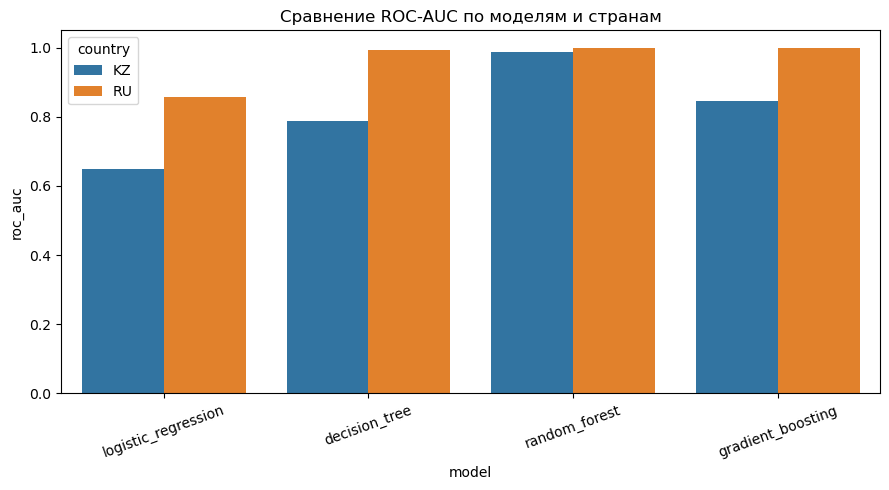

In [2]:
if comp_path.exists():
    plt.figure(figsize=(9, 5))
    sns.barplot(data=df, x="model", y="roc_auc", hue="country")
    plt.title("Сравнение ROC-AUC по моделям и странам")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

country,KZ,RU
model,,
decision_tree,0.2854,0.9109
gradient_boosting,0.1128,0.9705
logistic_regression,0.2066,0.6323
random_forest,0.8167,0.9983


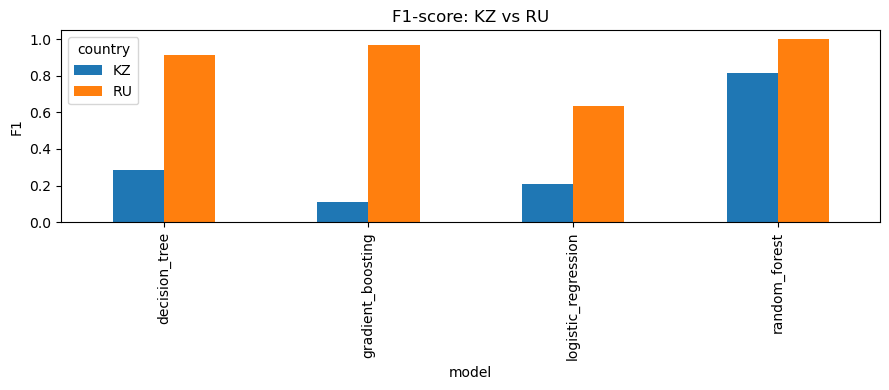

In [3]:
if comp_path.exists():
    pivot = df.pivot(index="model", columns="country", values="f1")
    display(pivot)
    pivot.plot(kind="bar", figsize=(9, 4), title="F1-score: KZ vs RU")
    plt.ylabel("F1")
    plt.tight_layout()
    plt.show()

### Выводы 

- Я сравнивал одни и те же алгоритмы на данных с одинаковой структурой признаков, но разным распределением (рынок / масштаб доходов).
- Разница метрик по странам может быть из‑за особенностей моих выборок и из‑за случайного train/test - в тексте я это оговариваю.
- Для практики важнее стабильность и интерпретируемость модели, а не только максимальный ROC-AUC на одной выборке.